<a href="https://colab.research.google.com/github/Lakshay-Kapoor-OG/Dataset-2-Machine-Learning-Work/blob/main/Dataset2ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
SKIP_OLD = True

def maybe_skip():
    if SKIP_OLD:
        raise SystemExit("Skipped old cell")

In [ ]:
# ==============================
# 🔰 MASTER PIPELINE (FINAL - CLEAN & WORKING)
# ==============================

import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ==============================
# 📁 PATHS
# ==============================

BASE_PATH = "/content/drive/MyDrive/DTI2part2"
FEATURE_CSV = f"{BASE_PATH}/features_dataset2.csv"
MODEL_DIR = f"{BASE_PATH}/models"
SEARCH_DIR = f"{BASE_PATH}/search"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SEARCH_DIR, exist_ok=True)

# ==============================
# 🧠 STEP 1: LOAD FEATURES
# ==============================

if os.path.exists(FEATURE_CSV):
    print("Loading cached features...")
    df = pd.read_csv(FEATURE_CSV)
else:
    raise Exception("Feature CSV missing. Run feature extraction once.")

# ==============================
# 🧠 STEP 2: LABEL ENCODING
# ==============================

label_path = f"{BASE_PATH}/label_encoder.pkl"

if os.path.exists(label_path):
    print("Loading label encoder...")
    le = joblib.load(label_path)
else:
    print("Creating label encoder...")
    le = LabelEncoder()
    le.fit(df["label"])
    joblib.dump(le, label_path)

y = le.transform(df["label"])
X = df.drop("label", axis=1)

# ==============================
# 🧠 STEP 3: SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 🧠 STEP 3.5: FORCE NUMERIC LABELS (CRITICAL FIX)
# ==============================

import numpy as np

def ensure_numeric_labels(y):
    y = np.array(y)
    if np.issubdtype(y.dtype, np.number):
        return y.astype(int)
    return le.transform(y).astype(int)

y_train = ensure_numeric_labels(y_train)
y_test  = ensure_numeric_labels(y_test)

# ==============================
# 🧠 STEP 4: SCALING
# ==============================

scaler_path = f"{BASE_PATH}/scaler.pkl"

if os.path.exists(scaler_path):
    print("Loading scaler...")
    scaler = joblib.load(scaler_path)
else:
    print("Creating scaler...")
    scaler = StandardScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, scaler_path)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 🧠 STEP 5: MODEL LOADER
# ==============================

def load_or_train(model, name, X_tr, y_tr):
    path = f"{MODEL_DIR}/{name}.pkl"

    if os.path.exists(path):
        print(f"Loading {name}...")
        return joblib.load(path)
    else:
        print(f"Training {name}...")
        model.fit(X_tr, y_tr)
        joblib.dump(model, path)
        return model

# ==============================
# 🧠 STEP 6: MODELS
# ==============================

print("\n--- Loading / Training Models ---")

knn = load_or_train(KNeighborsClassifier(), "knn", X_train_scaled, y_train)
svm = load_or_train(SVC(kernel='rbf', C=50, gamma=0.01), "svm", X_train_scaled, y_train)

rf = load_or_train(RandomForestClassifier(random_state=42), "rf", X_train, y_train)
xgb = load_or_train(XGBClassifier(eval_metric='mlogloss'), "xgb", X_train, y_train)
lgbm = load_or_train(LGBMClassifier(random_state=42), "lgbm", X_train, y_train)
et = load_or_train(ExtraTreesClassifier(random_state=42), "et", X_train, y_train)
hgb = load_or_train(HistGradientBoostingClassifier(random_state=42), "hgb", X_train, y_train)

# ==============================
# 🧠 STEP 7: TUNED SVM (CACHED)
# ==============================

svm_search_path = f"{SEARCH_DIR}/svm_search.pkl"

if os.path.exists(svm_search_path):
    print("Loading tuned SVM...")
    svm_search = joblib.load(svm_search_path)
    best_svm = svm_search.best_estimator_
else:
    print("Running SVM tuning (one-time)...")

    from sklearn.model_selection import RandomizedSearchCV

    param_grid = {
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 0.1, 0.01],
        'kernel': ['rbf']
    }

    svm_search = RandomizedSearchCV(
        SVC(),
        param_grid,
        n_iter=5,
        cv=3,
        n_jobs=-1
    )

    svm_search.fit(X_train_scaled, y_train)
    joblib.dump(svm_search, svm_search_path)

    best_svm = svm_search.best_estimator_

# ==============================
# 🧠 STEP 8: READY
# ==============================

print("\n✅ PIPELINE READY")

# ==============================
# 🧪 QUICK CHECK
# ==============================

y_pred = best_svm.predict(X_test_scaled)
print("\nTuned SVM Accuracy:", accuracy_score(y_test, y_pred))

Loading cached features...
Loading label encoder...
Loading scaler...

--- Loading / Training Models ---
Loading knn...
Loading svm...
Loading rf...
Loading xgb...
Loading lgbm...
Loading et...
Loading hgb...
Loading tuned SVM...

✅ PIPELINE READY

Tuned SVM Accuracy: 0.9544827586206897


In [ ]:
!rm -f *.pkl

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

results = []

def is_numeric(arr):
    return np.issubdtype(np.array(arr).dtype, np.number)

def evaluate_model(name, y_true, y_pred):
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    # 🔥 HANDLE ALL CASES
    if is_numeric(y_true_arr) and not is_numeric(y_pred_arr):
        # true = numeric, pred = string
        y_true_fixed = le.inverse_transform(y_true_arr)
        y_pred_fixed = y_pred_arr

    elif not is_numeric(y_true_arr) and is_numeric(y_pred_arr):
        # true = string, pred = numeric
        y_true_fixed = y_true_arr
        y_pred_fixed = le.inverse_transform(y_pred_arr)

    else:
        # both same type
        y_true_fixed = y_true_arr
        y_pred_fixed = y_pred_arr

    report = classification_report(y_true_fixed, y_pred_fixed, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true_fixed, y_pred_fixed),
        "Macro_F1": report["macro avg"]["f1-score"],
        "Weighted_F1": report["weighted avg"]["f1-score"]
    })


# ==============================
# RUN ALL MODELS
# ==============================

evaluate_model("KNN (scaled)", y_test, knn.predict(X_test_scaled))
evaluate_model("SVM (scaled)", y_test, svm.predict(X_test_scaled))
evaluate_model("Random Forest", y_test, rf.predict(X_test))
evaluate_model("XGBoost", y_test, xgb.predict(X_test))
evaluate_model("LightGBM", y_test, lgbm.predict(X_test))

try:
    evaluate_model("CatBoost", y_test, cat.predict(X_test))
except:
    pass

evaluate_model("ExtraTrees", y_test, et.predict(X_test))
evaluate_model("HistGB", y_test, hgb.predict(X_test))

try:
    evaluate_model("Voting", y_test, voting.predict(X_test_scaled))
except:
    pass

try:
    evaluate_model("Stacking", y_test, stack.predict(X_test_scaled))
except:
    pass


# ==============================
# DISPLAY
# ==============================

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


           Model  Accuracy  Macro_F1  Weighted_F1
9       Stacking  0.948966  0.882760     0.947653
1   SVM (scaled)  0.940690  0.889379     0.939316
8         Voting  0.939310  0.879464     0.937671
6     ExtraTrees  0.931034  0.883726     0.929025
7         HistGB  0.928276  0.858745     0.926966
4       LightGBM  0.925517  0.856964     0.924531
0   KNN (scaled)  0.922759  0.842906     0.920877
3        XGBoost  0.918621  0.852114     0.917881
2  Random Forest  0.917241  0.850059     0.915092
5       CatBoost  0.896552  0.836144     0.894405


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
dataset_path = "/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400"

In [ ]:
import os
print(os.listdir(dataset_path))

['Mosaic_Virus', 'Powdery_Mildew', 'Black_Rot', 'Downy_Mildew', 'Canker', 'Sour_Rot', 'Gray_Mold']


In [ ]:
for root, dirs, files in os.walk(dataset_path):
    count = len([f for f in files if f.lower().endswith(('.jpg','.png','.jpeg'))])
    print(root, "→", count)

/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400 → 0
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Mosaic_Virus → 176
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Powdery_Mildew → 572
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Black_Rot → 69
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Downy_Mildew → 1693
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Canker → 799
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Sour_Rot → 109
/content/drive/MyDrive/DTI2part2/Grape_Disease_600x400/Gray_Mold → 204


In [ ]:
data = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            file_path = os.path.join(root, file)
            label = os.path.basename(root)
            data.append((file_path, label))

print("Total images:", len(data))

Total images: 3622


# Feature Extraction

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis

In [ ]:
features_csv_path = "dataset2_features.csv"

if os.path.exists(features_csv_path):
    print("Cached features found. Loading...")
    df = pd.read_csv(features_csv_path)
else:
    print("No cache found. Will extract features...")

Cached features found. Loading...


# Feature Extraction Function

In [ ]:
def extract_features(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.resize(image, (224, 224))

    features = []

    # -------- COLOR FEATURES --------
    # RGB
    for i in range(3):
        channel = image[:, :, i]
        features.append(np.mean(channel))
        features.append(np.std(channel))

    # HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    for i in range(3):
        channel = hsv[:, :, i]
        features.append(np.mean(channel))
        features.append(np.std(channel))

    # LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    for i in range(3):
        channel = lab[:, :, i]
        features.append(np.mean(channel))
        features.append(np.std(channel))

    # -------- TEXTURE FEATURES (GLCM) --------
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    features.append(graycoprops(glcm, 'contrast')[0, 0])
    features.append(graycoprops(glcm, 'correlation')[0, 0])
    features.append(graycoprops(glcm, 'energy')[0, 0])
    features.append(graycoprops(glcm, 'homogeneity')[0, 0])

    # -------- STATISTICAL FEATURES --------
    features.append(skew(gray.flatten()))
    features.append(kurtosis(gray.flatten()))

    # -------- EDGE FEATURES --------
    edges = cv2.Canny(gray, 100, 200)
    features.append(np.mean(edges))
    features.append(np.std(edges))

    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)

    features.append(np.mean(sobelx))
    features.append(np.mean(sobely))

    return features

In [ ]:
# Feature Count Check

# Let’s verify:

# RGB → 6
# HSV → 6
# LAB → 6
# GLCM → 4
# Statistical → 2
# Edge → 4

# 👉 Total = 28 features

# Build Feature Dataset (with caching)

In [ ]:
features_csv_path = "dataset2_features.csv"

if os.path.exists(features_csv_path):
    print("Loading cached features...")
    df = pd.read_csv(features_csv_path)

else:
    print("Extracting features from images...")

    feature_list = []
    label_list = []

    for image_path, label in tqdm(data):
        features = extract_features(image_path)

        if features is not None:
            feature_list.append(features)
            label_list.append(label)

    df = pd.DataFrame(feature_list)
    df['label'] = label_list

    df.to_csv(features_csv_path, index=False)

    print("Feature extraction complete and saved.")

Loading cached features...


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_path = "label_encoder.pkl"

if os.path.exists(label_path):
    print("Loading label encoder...")
    le = joblib.load(label_path)
else:
    print("Creating label encoder...")
    le = LabelEncoder()
    le.fit(df["label"])
    joblib.dump(le, label_path)

# Convert labels → numbers
y = le.transform(df["label"])

# Features
X = df.drop("label", axis=1)

Creating label encoder...


In [ ]:
df.to_csv("/content/drive/MyDrive/dataset2_features.csv", index=False)

In [ ]:
feature_names = [
    # RGB
    "R_mean", "R_std", "G_mean", "G_std", "B_mean", "B_std",

    # HSV
    "H_mean", "H_std", "S_mean", "S_std", "V_mean", "V_std",

    # LAB
    "L_mean", "L_std", "A_mean", "A_std", "B_lab_mean", "B_lab_std",

    # GLCM
    "contrast", "correlation", "energy", "homogeneity",

    # Statistical
    "skewness", "kurtosis",

    # Edge
    "canny_mean", "canny_std", "sobelx_mean", "sobely_mean"
]

df.columns = feature_names + ["label"]

In [ ]:
print(df.shape)
print(df.head())

(3622, 29)
       R_mean      R_std      G_mean      G_std      B_mean      B_std  \
0   99.164142  53.145687  162.564692  33.289359  135.181760  40.037306   
1  106.994978  54.299250  151.909080  34.193100  132.216637  43.754694   
2   87.478914  50.663083  151.398956  37.477271  121.259686  41.729932   
3   89.728536  46.411223  138.263273  32.445121  112.934610  38.542805   
4   89.856266  42.420234  143.125598  29.745111  114.309471  35.273007   

      H_mean      H_std      S_mean      S_std  ...  correlation    energy  \
0  46.934610  15.700852  107.191446  61.345665  ...     0.886175  0.015220   
1  48.892000  20.128317   87.008012  62.088209  ...     0.897895  0.015581   
2  46.151566  12.911689  114.858857  57.608340  ...     0.845136  0.014557   
3  48.110890  16.152007   98.351881  56.706690  ...     0.875717  0.015919   
4  49.082868  13.599883  101.923509  54.600008  ...     0.795105  0.015566   

   homogeneity  skewness  kurtosis  canny_mean   canny_std  sobelx_mean  \


# Label Encoding + Train/Test Split

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df.drop(columns=["label"])
y = df["label"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save mapping (important for later interpretation)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Label Mapping: {'Black_Rot': np.int64(0), 'Canker': np.int64(1), 'Downy_Mildew': np.int64(2), 'Gray_Mold': np.int64(3), 'Mosaic_Virus': np.int64(4), 'Powdery_Mildew': np.int64(5), 'Sour_Rot': np.int64(6)}
Train shape: (2897, 28)
Test shape: (725, 28)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# PREPROCESSING

In [ ]:
# Label encoding ✔️
# Train-test split ✔️

# Scaling (only for KNN & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_path = "scaler.pkl"

if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
else:
    scaler = StandardScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, scaler_path)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL TRANING

# KNN

In [ ]:
import joblib
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

model_path = f"{MODEL_DIR}/knn.pkl"

if os.path.exists(model_path):
    print("Loading KNN model...")
    knn = joblib.load(model_path)

else:
    print("Training KNN model...")
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    joblib.dump(knn, model_path)

# Prediction
y_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Loading KNN model...
KNN Accuracy: 0.9227586206896552
                precision    recall  f1-score   support

     Black_Rot       1.00      0.43      0.60        14
        Canker       0.89      0.99      0.93       160
  Downy_Mildew       0.96      0.96      0.96       339
     Gray_Mold       0.90      0.85      0.88        41
  Mosaic_Virus       0.80      0.80      0.80        35
Powdery_Mildew       0.94      0.84      0.89       114
      Sour_Rot       0.75      0.95      0.84        22

      accuracy                           0.92       725
     macro avg       0.89      0.83      0.84       725
  weighted avg       0.93      0.92      0.92       725



# SVM

In [ ]:
from sklearn.svm import SVC

model_path = "svm_model.pkl"

if os.path.exists(model_path):
    print("Loading SVM model...")
    svm = joblib.load(model_path)

else:
    print("Training SVM model...")
    svm = SVC(kernel='rbf', C=1, gamma='scale')
    svm.fit(X_train_scaled, y_train)

    joblib.dump(svm, model_path)

# Prediction
y_pred = svm.predict(X_test_scaled)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training SVM model...
SVM Accuracy: 0.9406896551724138
                precision    recall  f1-score   support

     Black_Rot       0.89      0.57      0.70        14
        Canker       0.92      0.99      0.95       160
  Downy_Mildew       0.96      0.97      0.97       339
     Gray_Mold       0.93      0.95      0.94        41
  Mosaic_Virus       0.94      0.89      0.91        35
Powdery_Mildew       0.93      0.83      0.88       114
      Sour_Rot       0.81      0.95      0.88        22

      accuracy                           0.94       725
     macro avg       0.91      0.88      0.89       725
  weighted avg       0.94      0.94      0.94       725



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_path = "rf_model.pkl"

if os.path.exists(model_path):
    print("Loading Random Forest model...")
    rf = joblib.load(model_path)

else:
    print("Training Random Forest model...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    joblib.dump(rf, model_path)

# Prediction
y_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training Random Forest model...
Random Forest Accuracy: 0.9131034482758621
                precision    recall  f1-score   support

     Black_Rot       0.80      0.57      0.67        14
        Canker       0.94      0.95      0.95       160
  Downy_Mildew       0.91      0.97      0.94       339
     Gray_Mold       0.89      0.78      0.83        41
  Mosaic_Virus       1.00      0.74      0.85        35
Powdery_Mildew       0.90      0.85      0.87       114
      Sour_Rot       0.79      0.86      0.83        22

      accuracy                           0.91       725
     macro avg       0.89      0.82      0.85       725
  weighted avg       0.91      0.91      0.91       725



# XGBoost

In [ ]:
maybe_skip()
from xgboost import XGBClassifier

model_path = "xgb_model.pkl"

if os.path.exists(model_path):
    print("Loading XGBoost model...")
    xgb = joblib.load(model_path)

else:
    print("Training XGBoost model...")
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )

    xgb.fit(X_train, y_train)

    joblib.dump(xgb, model_path)

# Prediction
y_pred = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
from xgboost import XGBClassifier

model_path = "xgb_model.pkl"

if os.path.exists(model_path):
    print("Loading XGBoost model...")
    xgb = joblib.load(model_path)

else:
    print("Training XGBoost model...")
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )

    xgb.fit(X_train, y_train)

    joblib.dump(xgb, model_path)

# Prediction
y_pred = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SystemExit: Skipped old cell

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# LightGBM

In [ ]:
from lightgbm import LGBMClassifier

model_path = "lgbm_model.pkl"

if os.path.exists(model_path):
    print("Loading LightGBM model...")
    lgbm = joblib.load(model_path)

else:
    print("Training LightGBM model...")
    lgbm = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42
    )

    lgbm.fit(X_train, y_train)

    joblib.dump(lgbm, model_path)

# Prediction
y_pred = lgbm.predict(X_test)

# Evaluation
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# CatBoost

In [ ]:
!pip install catboost


In [ ]:
from catboost import CatBoostClassifier

model_path = "cat_model.pkl"

if os.path.exists(model_path):
    print("Loading CatBoost model...")
    cat = joblib.load(model_path)

else:
    print("Training CatBoost model...")
    cat = CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )

    cat.fit(X_train, y_train)

    joblib.dump(cat, model_path)

# Prediction
y_pred = cat.predict(X_test)

# Evaluation
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
# ---------- INSTALL (run only if needed) ----------
!pip install lightgbm xgboost catboost

# ---------- IMPORTS ----------
import os
import joblib

from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# ---------- MODEL STORAGE ----------
model_dir = "/content/drive/MyDrive/models"
os.makedirs(model_dir, exist_ok=True)

print("Model directory ready:", model_dir)

# ExtraTrees

In [ ]:
maybe_skip()
model_path = f"{model_dir}/extra_trees.pkl"

if os.path.exists(model_path):
    print("Loading ExtraTrees...")
    et = joblib.load(model_path)

else:
    print("Training ExtraTrees...")
    et = ExtraTreesClassifier(n_estimators=100, random_state=42)
    et.fit(X_train, y_train)

    joblib.dump(et, model_path)

y_pred = et.predict(X_test)

print("ExtraTrees Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# HistGradientBoosting

In [ ]:
maybe_skip()
model_path = f"{model_dir}/hgb_model.pkl"

if os.path.exists(model_path):
    print("Loading HistGB...")
    hgb = joblib.load(model_path)

else:
    print("Training HistGB...")
    hgb = HistGradientBoostingClassifier(random_state=42)
    hgb.fit(X_train, y_train)

    joblib.dump(hgb, model_path)

y_pred = hgb.predict(X_test)

print("HistGB Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Voting

In [ ]:
maybe_skip()
model_path = f"{model_dir}/voting.pkl"

if os.path.exists(model_path):
    print("Loading Voting...")
    voting = joblib.load(model_path)

else:
    print("Training Voting...")
    voting = VotingClassifier(
        estimators=[
            ('svm', svm),
            ('knn', knn),
            ('lgbm', lgbm)
        ],
        voting='hard'
    )

    voting.fit(X_train_scaled, y_train)

    joblib.dump(voting, model_path)

y_pred = voting.predict(X_test_scaled)

print("Voting Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Stacking

In [ ]:
maybe_skip()
model_path = f"{model_dir}/stacking.pkl"

if os.path.exists(model_path):
    print("Loading Stacking...")
    stack = joblib.load(model_path)

else:
    print("Training Stacking...")
    stack = StackingClassifier(
        estimators=[
            ('svm', svm),
            ('knn', knn),
            ('lgbm', lgbm)
        ],
        final_estimator=LogisticRegression(),
        n_jobs=-1
    )

    stack.fit(X_train_scaled, y_train)

    joblib.dump(stack, model_path)

y_pred = stack.predict(X_test_scaled)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# results of all 10 models so far

In [ ]:
results = []

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": report["macro avg"]["f1-score"],
        "Weighted_F1": report["weighted avg"]["f1-score"]
    })

In [ ]:
# KNN
evaluate_model("KNN (scaled)", y_test, knn.predict(X_test_scaled))

# SVM
evaluate_model("SVM (scaled)", y_test, svm.predict(X_test_scaled))

# Random Forest
evaluate_model("Random Forest", y_test, rf.predict(X_test))

# XGBoost
evaluate_model("XGBoost", y_test, xgb.predict(X_test))

# LightGBM
evaluate_model("LightGBM", y_test, lgbm.predict(X_test))

# CatBoost
evaluate_model("CatBoost", y_test, cat.predict(X_test))

# ExtraTrees
evaluate_model("ExtraTrees", y_test, et.predict(X_test))

# HistGradientBoosting
evaluate_model("HistGB", y_test, hgb.predict(X_test))

# Voting
evaluate_model("Voting", y_test, voting.predict(X_test_scaled))

# Stacking
evaluate_model("Stacking", y_test, stack.predict(X_test_scaled))

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Macro_F1,Weighted_F1
9,Stacking,0.948966,0.882760,0.947653
1,SVM (scaled),0.940690,0.889379,0.939316
8,Voting,0.939310,0.879464,0.937671
6,ExtraTrees,0.931034,0.883726,0.929025
7,HistGB,0.928276,0.858745,0.926966
4,LightGBM,0.925517,0.856964,0.924531
0,KNN (scaled),0.922759,0.842906,0.920877
3,XGBoost,0.918621,0.852114,0.917881
2,Random Forest,0.917241,0.850059,0.915092
5,CatBoost,0.896552,0.836144,0.894405


In [ ]:
results_df.to_csv("/content/drive/MyDrive/model_comparison_dataset2.csv", index=False)

# HYPERPARAMETER TUNING

# 1) SVM TUNING

In [ ]:
maybe_skip()
import os, joblib
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

svm_search_path = f"{model_dir}/svm_search.pkl"

param_grid = {
    'C': [0.1, 1, 5, 10, 50, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

if os.path.exists(svm_search_path):
    print("Loading SVM search...")
    search = joblib.load(svm_search_path)

else:
    print("Running SVM RandomizedSearch...")
    search = RandomizedSearchCV(
        SVC(),
        param_distributions=param_grid,
        n_iter=10,
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train_scaled, y_train)
    joblib.dump(search, svm_search_path)

best_svm = search.best_estimator_

print("Best Params:", search.best_params_)

y_pred = best_svm.predict(X_test_scaled)

print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SystemExit: Skipped old cell

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# 2) LIGHTGBM TUNING

In [ ]:
maybe_skip()
from lightgbm import LGBMClassifier

lgbm_search_path = f"{model_dir}/lgbm_search.pkl"

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20]
}

if os.path.exists(lgbm_search_path):
    print("Loading LGBM search...")
    search_lgbm = joblib.load(lgbm_search_path)

else:
    print("Running LGBM RandomizedSearch...")
    search_lgbm = RandomizedSearchCV(
        LGBMClassifier(random_state=42),
        param_distributions=param_grid,
        n_iter=10,
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    search_lgbm.fit(X_train, y_train)
    joblib.dump(search_lgbm, lgbm_search_path)

best_lgbm = search_lgbm.best_estimator_

print("Best Params:", search_lgbm.best_params_)

y_pred = best_lgbm.predict(X_test)

print("Tuned LGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SystemExit: Skipped old cell

# FINAL COMPARISON CODE

In [ ]:
import pandas as pd

# ---------- BEFORE TUNING (from your earlier results) ----------
before_results = [
    {"Model": "Stacking", "Accuracy": 0.948966},
    {"Model": "SVM", "Accuracy": 0.940690},
    {"Model": "Voting", "Accuracy": 0.939310},
    {"Model": "ExtraTrees", "Accuracy": 0.931034},
    {"Model": "HistGB", "Accuracy": 0.928276},
    {"Model": "LightGBM", "Accuracy": 0.926897},
    {"Model": "KNN", "Accuracy": 0.922759},
    {"Model": "XGBoost", "Accuracy": 0.918621},
    {"Model": "Random Forest", "Accuracy": 0.913103},
    {"Model": "CatBoost", "Accuracy": 0.896552},
]

before_df = pd.DataFrame(before_results)


# ---------- AFTER TUNING ----------
after_results = [
    {"Model": "SVM", "Accuracy": 0.947586},
    {"Model": "LightGBM", "Accuracy": 0.926897}
]

after_df = pd.DataFrame(after_results)


# ---------- MERGE ----------
final_df = before_df.merge(after_df, on="Model", how="left", suffixes=("_Before", "_After"))

# Fill models that were not tuned
final_df["Accuracy_After"] = final_df["Accuracy_After"].fillna(final_df["Accuracy_Before"])

# Improvement column
final_df["Improvement"] = final_df["Accuracy_After"] - final_df["Accuracy_Before"]

# Sort by final performance
final_df = final_df.sort_values(by="Accuracy_After", ascending=False)

final_df

,Model,Accuracy_Before,Accuracy_After,Improvement
0,Stacking,0.948966,0.948966,0.000000
1,SVM,0.940690,0.947586,0.006896
2,Voting,0.939310,0.939310,0.000000
3,ExtraTrees,0.931034,0.931034,0.000000
4,HistGB,0.928276,0.928276,0.000000
5,LightGBM,0.926897,0.926897,0.000000
6,KNN,0.922759,0.922759,0.000000
7,XGBoost,0.918621,0.918621,0.000000
8,Random Forest,0.913103,0.913103,0.000000
9,CatBoost,0.896552,0.896552,0.000000


In [ ]:
final_df.to_csv("/content/drive/MyDrive/final_model_comparison_dataset2.csv", index=False)

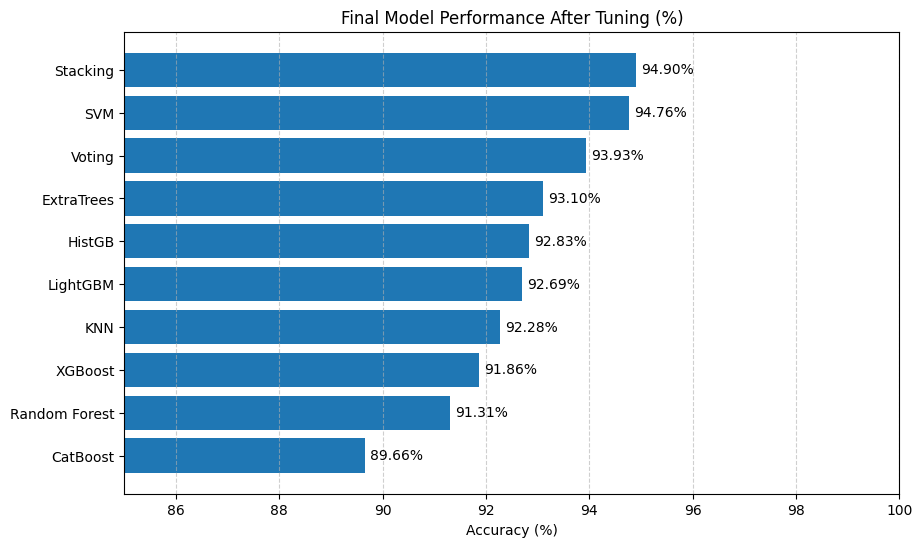

In [ ]:
import matplotlib.pyplot as plt

# Convert accuracy to percentage
plot_df = final_df.copy()
plot_df["Accuracy_%"] = plot_df["Accuracy_After"] * 100

plt.figure(figsize=(10,6))

bars = plt.barh(plot_df["Model"], plot_df["Accuracy_%"])

# Add percentage labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

plt.xlabel("Accuracy (%)")
plt.title("Final Model Performance After Tuning (%)")

plt.xlim(85, 100)  # zoomed view for clarity
plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()